In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [2]:
df = pd.read_csv(
    r"D:\Guvi\Projects\ride_flow_ai\data\preprocessed\cleaned_rides.csv"
)

print(df.head())

   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         2  2024-01-01 00:57:55   2024-01-01 01:17:43              1.0   
1         1  2024-01-01 00:03:00   2024-01-01 00:09:36              1.0   
2         1  2024-01-01 00:17:06   2024-01-01 00:35:01              1.0   
3         1  2024-01-01 00:36:38   2024-01-01 00:44:56              1.0   
4         1  2024-01-01 00:46:51   2024-01-01 00:52:57              1.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0           1.72         1.0                  N           186            79   
1           1.80         1.0                  N           140           236   
2           4.70         1.0                  N           236            79   
3           1.40         1.0                  N            79           211   
4           0.80         1.0                  N           211           148   

   payment_type  ...  improvement_surcharge  total_amount  \
0            

In [3]:
demand_df = (
    df.groupby(
        ['PULocationID','pickup_hour']
    )
    .size()
    .reset_index(name='ride_count')
)

print(demand_df.head())

   PULocationID  pickup_hour  ride_count
0             1            5           2
1             1            6           5
2             1            7           3
3             1            8           1
4             1           10           2


In [4]:
np.random.seed(42)

demand_df['available_drivers'] = (
    demand_df['ride_count']
    -
    np.random.randint(
        5,
        30,
        size=len(demand_df)
    )
)

In [5]:
demand_df['available_drivers'] = (
    demand_df['available_drivers']
    .clip(lower=1)
)

In [6]:
print(demand_df.head())

   PULocationID  pickup_hour  ride_count  available_drivers
0             1            5           2                  1
1             1            6           5                  1
2             1            7           3                  1
3             1            8           1                  1
4             1           10           2                  1


In [7]:
X = demand_df[
    ['PULocationID','pickup_hour']
]

y = demand_df['available_drivers']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
supply_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

supply_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [10]:
predictions = supply_model.predict(X_test)

In [11]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 11.097847619047618
RMSE : 23.09880363424334
R2 Score : 0.8822291287850409


In [12]:
joblib.dump(
    supply_model,
    r"D:\Guvi\Projects\ride_flow_ai\models\supply_prediction_model.pkl"
)

print("Supply Model Saved")

Supply Model Saved


In [13]:
demand_df['gap'] = (
    demand_df['ride_count']
    -
    demand_df['available_drivers']
)

print(demand_df.head())

   PULocationID  pickup_hour  ride_count  available_drivers  gap
0             1            5           2                  1    1
1             1            6           5                  1    4
2             1            7           3                  1    2
3             1            8           1                  1    0
4             1           10           2                  1    1


In [14]:
def calculate_surge(demand,supply):

    ratio = demand / supply

    if ratio <= 1:
        return 1.0

    elif ratio <= 1.2:
        return 1.2

    elif ratio <= 1.5:
        return 1.5

    elif ratio <= 2:
        return 2.0

    else:
        return 3.0

In [15]:
demand_df['surge_multiplier'] = demand_df.apply(
    lambda row: calculate_surge(
        row['ride_count'],
        row['available_drivers']
    ),
    axis=1
)

print(
    demand_df[
        ['ride_count',
         'available_drivers',
         'surge_multiplier']
    ].head()
)

   ride_count  available_drivers  surge_multiplier
0           2                  1               2.0
1           5                  1               3.0
2           3                  1               3.0
3           1                  1               1.0
4           2                  1               2.0


In [16]:
base_fare = 300

demand_df['dynamic_price'] = (
    base_fare
    *
    demand_df['surge_multiplier']
)

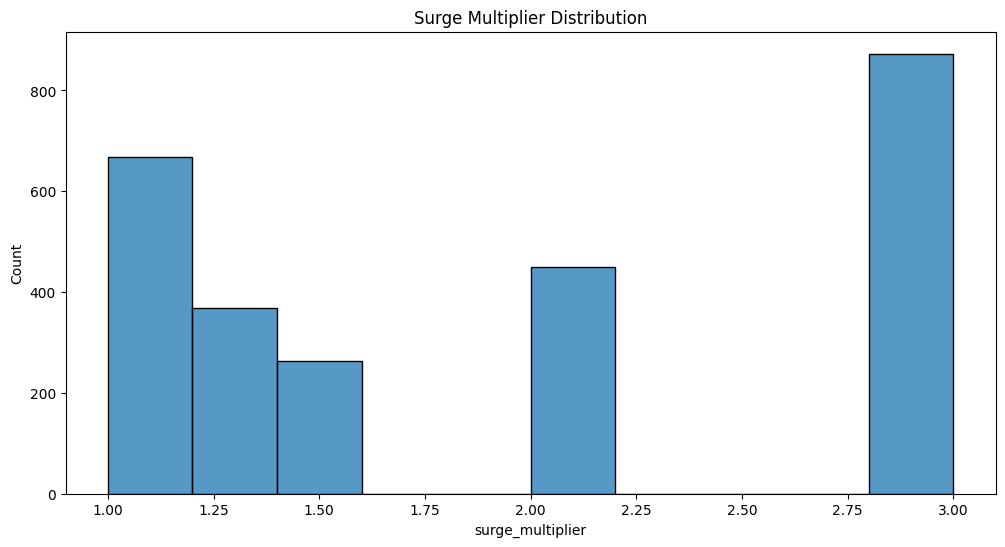

In [17]:
plt.figure(figsize=(12,6))

sns.histplot(
    demand_df['surge_multiplier'],
    bins=10
)

plt.title("Surge Multiplier Distribution")

plt.show()

In [18]:
top_surge = (
    demand_df.sort_values(
        by='surge_multiplier',
        ascending=False
    )
    .head(10)
)

print(top_surge)

      PULocationID  pickup_hour  ride_count  available_drivers  gap  \
9                1           17           4                  1    3   
2620           265           23           5                  1    4   
12               4            0          24                  1   23   
1                1            6           5                  1    4   
2                1            7           3                  1    2   
15               4            3          18                  1   17   
2609           265           10           4                  1    3   
2610           265           11           3                  1    2   
2611           265           12          10                  1    9   
2615           265           16           4                  1    3   

      surge_multiplier  dynamic_price  
9                  3.0          900.0  
2620               3.0          900.0  
12                 3.0          900.0  
1                  3.0          900.0  
2                 